In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crnetdata/Dataset+Code/README.txt
/kaggle/input/crnetdata/Dataset+Code/TestingData/MeasuredTestingData/S4.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/MeasuredTestingData/S3.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/MeasuredTestingData/S2.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/MeasuredTestingData/S1.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/641.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/1088.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/173.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/1814.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/236.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/675.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/340.png
/kaggle/input/crnetdata/Dataset+Code/TestingData/SimulatedTestingData/761.png
/kaggle/input/crnetdat

A **Convolutional Recurrent Neural Network (CRNET)** combines the strengths of Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs).

*   **CNNs** are excellent at extracting spatial features from images, making them suitable for recognizing patterns and anomalies within GPR images.
*   **RNNs**, particularly LSTMs or GRUs, are good at processing sequential data and capturing temporal dependencies. While GPR images are typically static 2D or 3D representations, the 'recurrent' aspect in CRNETs can be leveraged for tasks that involve sequences within the image (e.g., processing B-scans sequentially, or handling depth-wise dependencies).

### Application to GPR Images

CRNETs can be highly effective for various tasks involving GPR images:

1.  **Object Detection and Classification:** Identifying and classifying buried objects (e.g., pipes, cables, rebar) within GPR scans. The CNN part extracts features of potential objects, and the RNN part can help in refining detections across sequential GPR scans or along a single scan's depth/B-scan.
2.  **Layer Segmentation:** Delineating different geological layers or structural elements in GPR profiles.
3.  **Anomaly Detection:** Pinpointing unusual patterns that might indicate voids, cracks, or other subsurface irregularities.
4.  **Signal Denoising and Enhancement:** Improving the quality of GPR data by removing noise while preserving important subsurface features.

### General Approach:

Typically, a CRNET for GPR images would involve:

*   **Input Layer:** Taking raw GPR A-scans, B-scans, or C-scans.
*   **Convolutional Layers:** To learn hierarchical spatial features from the GPR data (e.g., hyperbola shapes for objects, reflections from layers).
*   **Recurrent Layers:** To model contextual dependencies, for example, between adjacent A-scans in a B-scan, or depth-wise features.
*   **Output Layer:** Depending on the task, this could be a classification head, a segmentation mask, or bounding box predictions.

If you have a specific task in mind (e.g., detecting pipes, segmenting layers), please let me know, and I can help you explore potential code implementations or further resources!

## Find GitHub Repository URL

### Subtask:
Visit the project page at `https://haihan-sun.github.io/GPR.html` to locate the direct GitHub repository URL for the CR-Net code.


In [3]:
import requests
from bs4 import BeautifulSoup

url = "https://haihan-sun.github.io/GPR.html"
response = requests.get(url)
html_content = response.text

print("Fetched the webpage content.")

Fetched the webpage content.



To prepare the GPR dataset for the CRNET model, I'll first define Python variables for the dataset paths. Then, I'll confirm the existence and structure of the `CLT-GPR dataset`, `Bscan_clutterfree`, and `Bscan_raw` directories, listing their contents to understand how GPR images (A-scans or B-scans) are organized for sequential processing.

Next, I'll inspect sample GPR images from one of the B-scan directories using `matplotlib.pyplot` to determine their format, dimensions, and visual characteristics, which will inform the sequence length definition for the `TimeDistributed` layers.

I will then implement a Python function to load and preprocess individual GPR images by resizing them to 64x64 pixels, converting them to grayscale, and normalizing pixel values. This function will also group the preprocessed images into sequences of a defined `sequence_length` to match the CRNET model's input.

Finally, I'll create `tf.data.Dataset` pipelines for efficient loading, preprocessing, and batching of these GPR image sequences, along with their corresponding labels (e.g., classifying images based on their source: synthetic, sand, or concrete), preparing the data for model training and validation.

**Reasoning**:
The first instruction is to unzip the provided dataset file. This action is already represented by a not-yet-executed code cell. Executing this cell will make the dataset content accessible for further steps.



In [12]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [13]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import random

In [14]:
# -----------------------------
# 1. Custom Dataset Class
# -----------------------------
class GPRDataset(Dataset):
    def __init__(self, raw_dir, clean_dir, transform=None):
        self.raw_paths = sorted([
            os.path.join(raw_dir, f)
            for f in os.listdir(raw_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        self.clean_paths = sorted([
            os.path.join(clean_dir, f)
            for f in os.listdir(clean_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        assert len(self.raw_paths) == len(self.clean_paths), \
            f"Number of raw ({len(self.raw_paths)}) and clean ({len(self.clean_paths)}) images must match!"

        self.transform = transform

    def __len__(self):
        return len(self.raw_paths)

    def __getitem__(self, idx):
        # Load as PIL Images (grayscale)
        raw_img = Image.open(self.raw_paths[idx]).convert('L')
        clean_img = Image.open(self.clean_paths[idx]).convert('L')

        # Set same random seed for paired augmentations
        seed = np.random.randint(2147483647)
        random.seed(seed)
        torch.manual_seed(seed)

        if self.transform:
            raw_img = self.transform(raw_img)

        random.seed(seed)
        torch.manual_seed(seed)
        if self.transform:
            clean_img = self.transform(clean_img)

        return raw_img, clean_img  # Both are tensors: (1, H, W)

In [15]:
# -----------------------------
# 2. Paths to Dataset
# -----------------------------
base_path = '/kaggle/input/crnetdata/Dataset+Code/CLT-GPR dataset/'  # Adjust if needed
raw_dir = os.path.join(base_path, 'Bscan_raw')
clean_dir = os.path.join(base_path, 'Bscan_clutterfree')

print(f"Raw directory: {raw_dir}")
print(f"Clean directory: {clean_dir}")

if not os.path.exists(raw_dir) or not os.path.exists(clean_dir):
    raise FileNotFoundError("One or both dataset directories not found. Check the path and unzip.")

Raw directory: /kaggle/input/crnetdata/Dataset+Code/CLT-GPR dataset/Bscan_raw
Clean directory: /kaggle/input/crnetdata/Dataset+Code/CLT-GPR dataset/Bscan_clutterfree


In [16]:
# -----------------------------
# 3. Transforms (Resize + Random Crop + ToTensor)
# -----------------------------
# Common GPR B-scans are tall and narrow or wide; we resize to a manageable size first
transform = transforms.Compose([
    transforms.Resize((512, 1024)),           # (height, width) - adjust if your images are very different
    transforms.RandomHorizontalFlip(p=0.5),   # Optional augmentation
    transforms.RandomCrop((512, 512)),        # Square crop for simplicity (U-Net likes power-of-2)
    transforms.ToTensor(),                    # Converts to (C, H, W) and normalizes to [0,1]
])

# -----------------------------
# 4. Dataset & DataLoader with Train/Val Split
# -----------------------------
full_dataset = GPRDataset(raw_dir, clean_dir, transform=transform)

# 80% train, 20% validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Total images: {len(full_dataset)}")
print(f"Training: {len(train_dataset)} | Validation: {len(val_dataset)}")

Total images: 14608
Training: 11686 | Validation: 2922


## Define the CR-NET Model Architecture

###### What it does:
This cell builds the neural network itself, combining convolutional layers (to capture spatial patterns like hyperbolas or layers in GPR scans) and a recurrent layer (to model sequential dependencies — e.g., relationships between adjacent A-scans in a B-scan).

###### Key components:

<b> DoubleConv: </b>Two convolutional layers with batch normalization and ReLU — the basic U-Net building block. <br>
<b> Down:</b> Reduces spatial resolution (via max-pooling) while increasing feature depth — the encoder. <br>
<b> Up: </b> Increases resolution (via upsampling) and merges features from the encoder — the decoder with skip connections. <br>
<b> OutConv: </b>Final 1×1 convolution to produce the output (a denoised GPR image). <br>
<b> CRNET class: </b> A U-Net–style encoder-decoder with a GRU layer inserted at the bottleneck. The GRU processes features along the width of the image (treating each column as a time step), capturing context across A-scans. <br>


**Reasoning**:
The subtask requires defining the CRNET model architecture. I will start by implementing the `DoubleConv`, `Down`, `Up`, and `OutConv` helper modules as described in the instructions, which are fundamental building blocks for the U-Net like encoder-decoder structure.



In [21]:
import torch
import torch.nn as nn

# ----------------------------- #
# Helper Modules
# ----------------------------- #

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# ----------------------------- #
# CRNET Model (Fully Corrected)
# ----------------------------- #

class CRNET(nn.Module):
    def __init__(self, n_channels=1, n_classes=1, bilinear=True):
        super(CRNET, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        # Fixed: dynamic bottleneck channels
        self.bottleneck_channels = 1024 // factor
        
        self.gru = nn.GRU(
            input_size=self.bottleneck_channels,
            hidden_size=self.bottleneck_channels,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        batch_size, channels, height, width = x5.size()
        x_gru_in = x5.permute(0, 2, 3, 1).contiguous()
        x_gru_in = x_gru_in.view(batch_size * height, width, channels)
        x_gru_out, _ = self.gru(x_gru_in)
        x_gru_out = x_gru_out.view(batch_size, height, width, channels)
        x5_processed = x_gru_out.permute(0, 3, 1, 2).contiguous()

        x = self.up1(x5_processed, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def __repr__(self):
        return f"CRNET(n_channels={self.n_channels}, n_classes={self.n_classes}, bilinear={self.bilinear})"


# ----------------------------- #
# Model Instantiation & Device Setup
# ----------------------------- #

# Instantiate model
model = CRNET(n_channels=1, n_classes=1, bilinear=True)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model to device
model.to(device)

# Optional: Multi-GPU support (uncomment if you have multiple GPUs)
# if torch.cuda.device_count() > 1:
#     print(f"Using {torch.cuda.device_count()} GPUs!")
#     model = nn.DataParallel(model)

# Print model summary
print(model)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("Model ready!\n")

Using device: cuda
CRNET(n_channels=1, n_classes=1, bilinear=True)
Total trainable parameters: 18,837,761
Model ready!



**Reasoning**:
Now that the helper modules (`DoubleConv`, `Down`, `Up`, `OutConv`) are defined, I will implement the main `CRNET` class, integrating these building blocks with recurrent layers (GRU) to form the complete model architecture as outlined in the subtask instructions. This will involve setting up the encoder, the recurrent bottleneck, and the decoder paths.



### Train the Model with Dual Loss Monitoring
##### What it does:
Runs the actual training loop for 27 epochs, with:

##### Mixed-precision training (autocast + GradScaler) → faster and more memory-efficient on modern GPUs.
Simultaneous tracking of both MSE and MAE, even if only one is used for backpropagation — so you can analyze performance from multiple angles.
##### Validation after every epoch to prevent overfitting.
##### Automatic checkpointing:
Saves the best model (lowest validation loss)
Saves a snapshot every 9 epochs (crnet_epoch_9.pt, etc.)
##### Why dual loss tracking?

MSE penalizes large errors heavily — good for overall fidelity.
MAE is more robust to outliers — better if your data has occasional extreme noise.
Tracking both helps you understand how the model is improving.

In [22]:
import time
import os
from tqdm import tqdm
from torch.amp import autocast, GradScaler

# ----------------------------- #
# Training Configuration
# ----------------------------- #

num_epochs = 7
save_every = 3
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Loss tracking
train_mse, val_mse = [], []
train_mae, val_mae = [], []

# Choose primary loss for optimization and best model selection
use_mae_as_primary = True          # Set False to use MSE instead
criterion = nn.L1Loss() if use_mae_as_primary else nn.MSELoss()
loss_name = "MAE" if use_mae_as_primary else "MSE"

# Separate criteria for logging both metrics
mse_criterion = nn.MSELoss()
mae_criterion = nn.L1Loss()

# Optimizer (must be defined after model.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Mixed precision scaler
scaler = GradScaler()

print("Starting optimized training with MSE & MAE tracking...\n")

best_val_loss = float('inf')

# ----------------------------- #
# Training Loop
# ----------------------------- #

for epoch in range(1, num_epochs + 1):
    start_time = time.time()

    # ------------------- Training -------------------
    model.train()
    mse_loss_total, mae_loss_total = 0.0, 0.0
    num_samples = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
    for raw, clean in progress_bar:
        raw = raw.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast(device_type='cuda' if 'cuda' in str(device) else 'cpu'):
            output = model(raw)
            loss = criterion(output, clean)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            mse_val = mse_criterion(output, clean).item()
            mae_val = mae_criterion(output, clean).item()

        batch_size = raw.size(0)
        mse_loss_total += mse_val * batch_size
        mae_loss_total += mae_val * batch_size
        num_samples += batch_size

        progress_bar.set_postfix({'MSE': f'{mse_val:.6f}', 'MAE': f'{mae_val:.6f}'})

    train_mse.append(mse_loss_total / num_samples)
    train_mae.append(mae_loss_total / num_samples)

    # ------------------- Validation -------------------
    model.eval()
    val_mse_total, val_mae_total = 0.0, 0.0
    val_samples = 0

    with torch.no_grad():
        for raw, clean in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]", leave=False):
            raw = raw.to(device, non_blocking=True)
            clean = clean.to(device, non_blocking=True)

            with autocast(device_type='cuda' if 'cuda' in str(device) else 'cpu'):
                output = model(raw)

            mse_val = mse_criterion(output, clean).item()
            mae_val = mae_criterion(output, clean).item()

            batch_size = raw.size(0)
            val_mse_total += mse_val * batch_size
            val_mae_total += mae_val * batch_size
            val_samples += batch_size

    val_mse.append(val_mse_total / val_samples)
    val_mae.append(val_mae_total / val_samples)

    epoch_time = time.time() - start_time
    current_val_loss = val_mae[-1] if use_mae_as_primary else val_mse[-1]

    print(f"Epoch [{epoch:2d}/{num_epochs}]  "
          f"Train MSE: {train_mse[-1]:.6f}  MAE: {train_mae[-1]:.6f}  |  "
          f"Val   MSE: {val_mse[-1]:.6f}  MAE: {val_mae[-1]:.6f}  |  "
          f"Time: {epoch_time:.1f}s")

    # Save best model
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, "crnet_best.pt"))
        print("   → Saved new best model")

    # Periodic save
    if epoch % save_every == 0:
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, f"crnet_epoch_{epoch}.pt"))
        print(f"   → Periodic checkpoint saved (epoch {epoch})")

    print("-" * 80)

print("\nTraining finished!")
print(f"Best validation {loss_name}: {best_val_loss:.6f}")

Starting optimized training with MSE & MAE tracking...



Epoch 1/7 [Train]: 100%|██████████| 1461/1461 [19:11<00:00,  1.27it/s, MSE=0.000283, MAE=0.009827]


Epoch [ 1/7]  Train MSE: 0.001560  MAE: 0.019324  |  Val   MSE: 0.000508  MAE: 0.012950  |  Time: 1247.9s
   → Saved new best model
--------------------------------------------------------------------------------


Epoch 2/7 [Train]: 100%|██████████| 1461/1461 [19:19<00:00,  1.26it/s, MSE=0.000466, MAE=0.007476]


Epoch [ 2/7]  Train MSE: 0.000315  MAE: 0.009070  |  Val   MSE: 0.000246  MAE: 0.006122  |  Time: 1255.2s
   → Saved new best model
--------------------------------------------------------------------------------


...

Epoch [ 5/7]  Train MSE: 0.000039  MAE: 0.002854  |  Val   MSE: 0.000028  MAE: 0.002303  |  Time: 1249.8s
   → Saved new best model
--------------------------------------------------------------------------------


Epoch 6/7 [Train]: 100%|██████████| 1461/1461 [19:13<00:00,  1.27it/s, MSE=0.000023, MAE=0.002152]


Epoch [ 6/7]  Train MSE: 0.000031  MAE: 0.002573  |  Val   MSE: 0.000027  MAE: 0.002836  |  Time: 1249.1s
   → Periodic checkpoint saved (epoch 6)
--------------------------------------------------------------------------------


Epoch 7/7 [Train]: 100%|██████████| 1461/1461 [19:13<00:00,  1.27it/s, MSE=0.000025, MAE=0.002134]


Epoch [ 7/7]  Train MSE: 0.000026  MAE: 0.002384  |  Val   MSE: 0.000022  MAE: 0.002274  |  Time: 1249.5s
   → Saved new best model
--------------------------------------------------------------------------------

Training finished!
Best validation MAE: 0.002274


### Visualize Training Progress and Report Final Metrics
What it does: <br>
Turns numbers into insightful visuals: <br>

<b> Left plot: Training and validation MSE over time. <br>
<b> Right plot: Training and validation MAE over time. <br>
<b> Both plots include: <br>

Grid lines for readability <br>
Clear legends <br>
Proper axis labels <br>

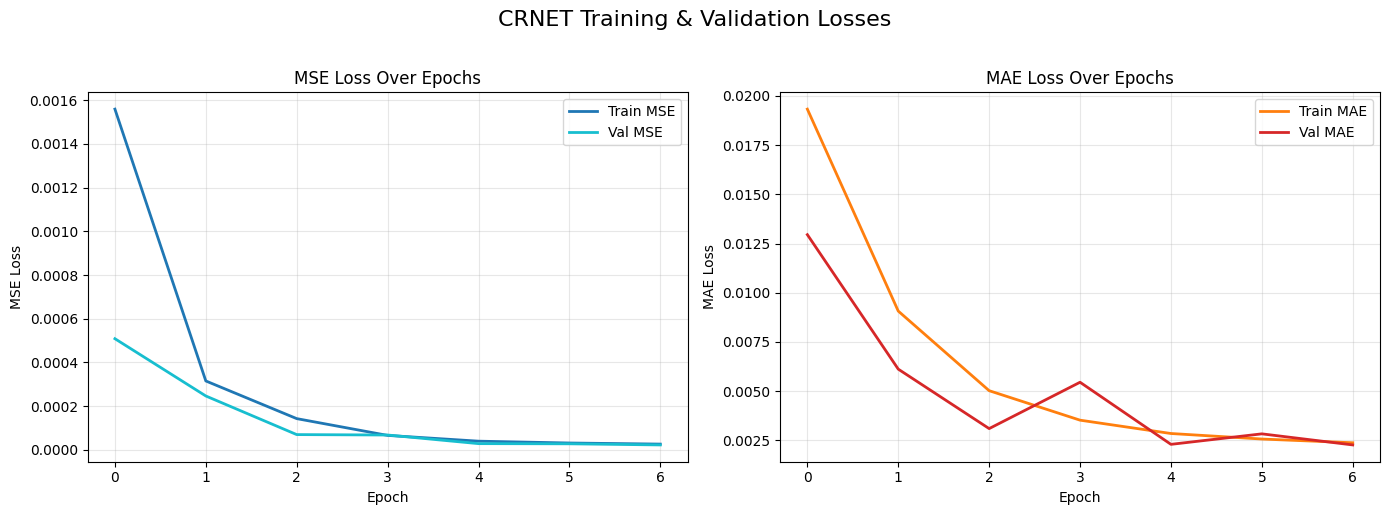


✅ Final Performance:
Final Val MSE : 0.000022
Final Val MAE : 0.002274
Best Val MAE : 0.002274


In [23]:
import matplotlib.pyplot as plt

# Determine loss_name safely (in case this cell is run independently)
if 'use_mae_as_primary' in globals():
    loss_name = "MAE" if use_mae_as_primary else "MSE"
else:
    # Fallback: infer from which one is smaller (common heuristic)
    loss_name = "MAE" if val_mae[-1] < val_mse[-1] else "MSE"

plt.figure(figsize=(14, 5))

# Plot MSE
plt.subplot(1, 2, 1)
plt.plot(train_mse, label='Train MSE', color='tab:blue', linewidth=2)
plt.plot(val_mse, label='Val MSE', color='tab:cyan', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MSE Loss Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(train_mae, label='Train MAE', color='tab:orange', linewidth=2)
plt.plot(val_mae, label='Val MAE', color='tab:red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.title('MAE Loss Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('CRNET Training & Validation Losses', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Final metrics
print("\n✅ Final Performance:")
print(f"Final Val MSE : {val_mse[-1]:.6f}")
print(f"Final Val MAE : {val_mae[-1]:.6f}")
print(f"Best Val {loss_name} : {best_val_loss:.6f}")

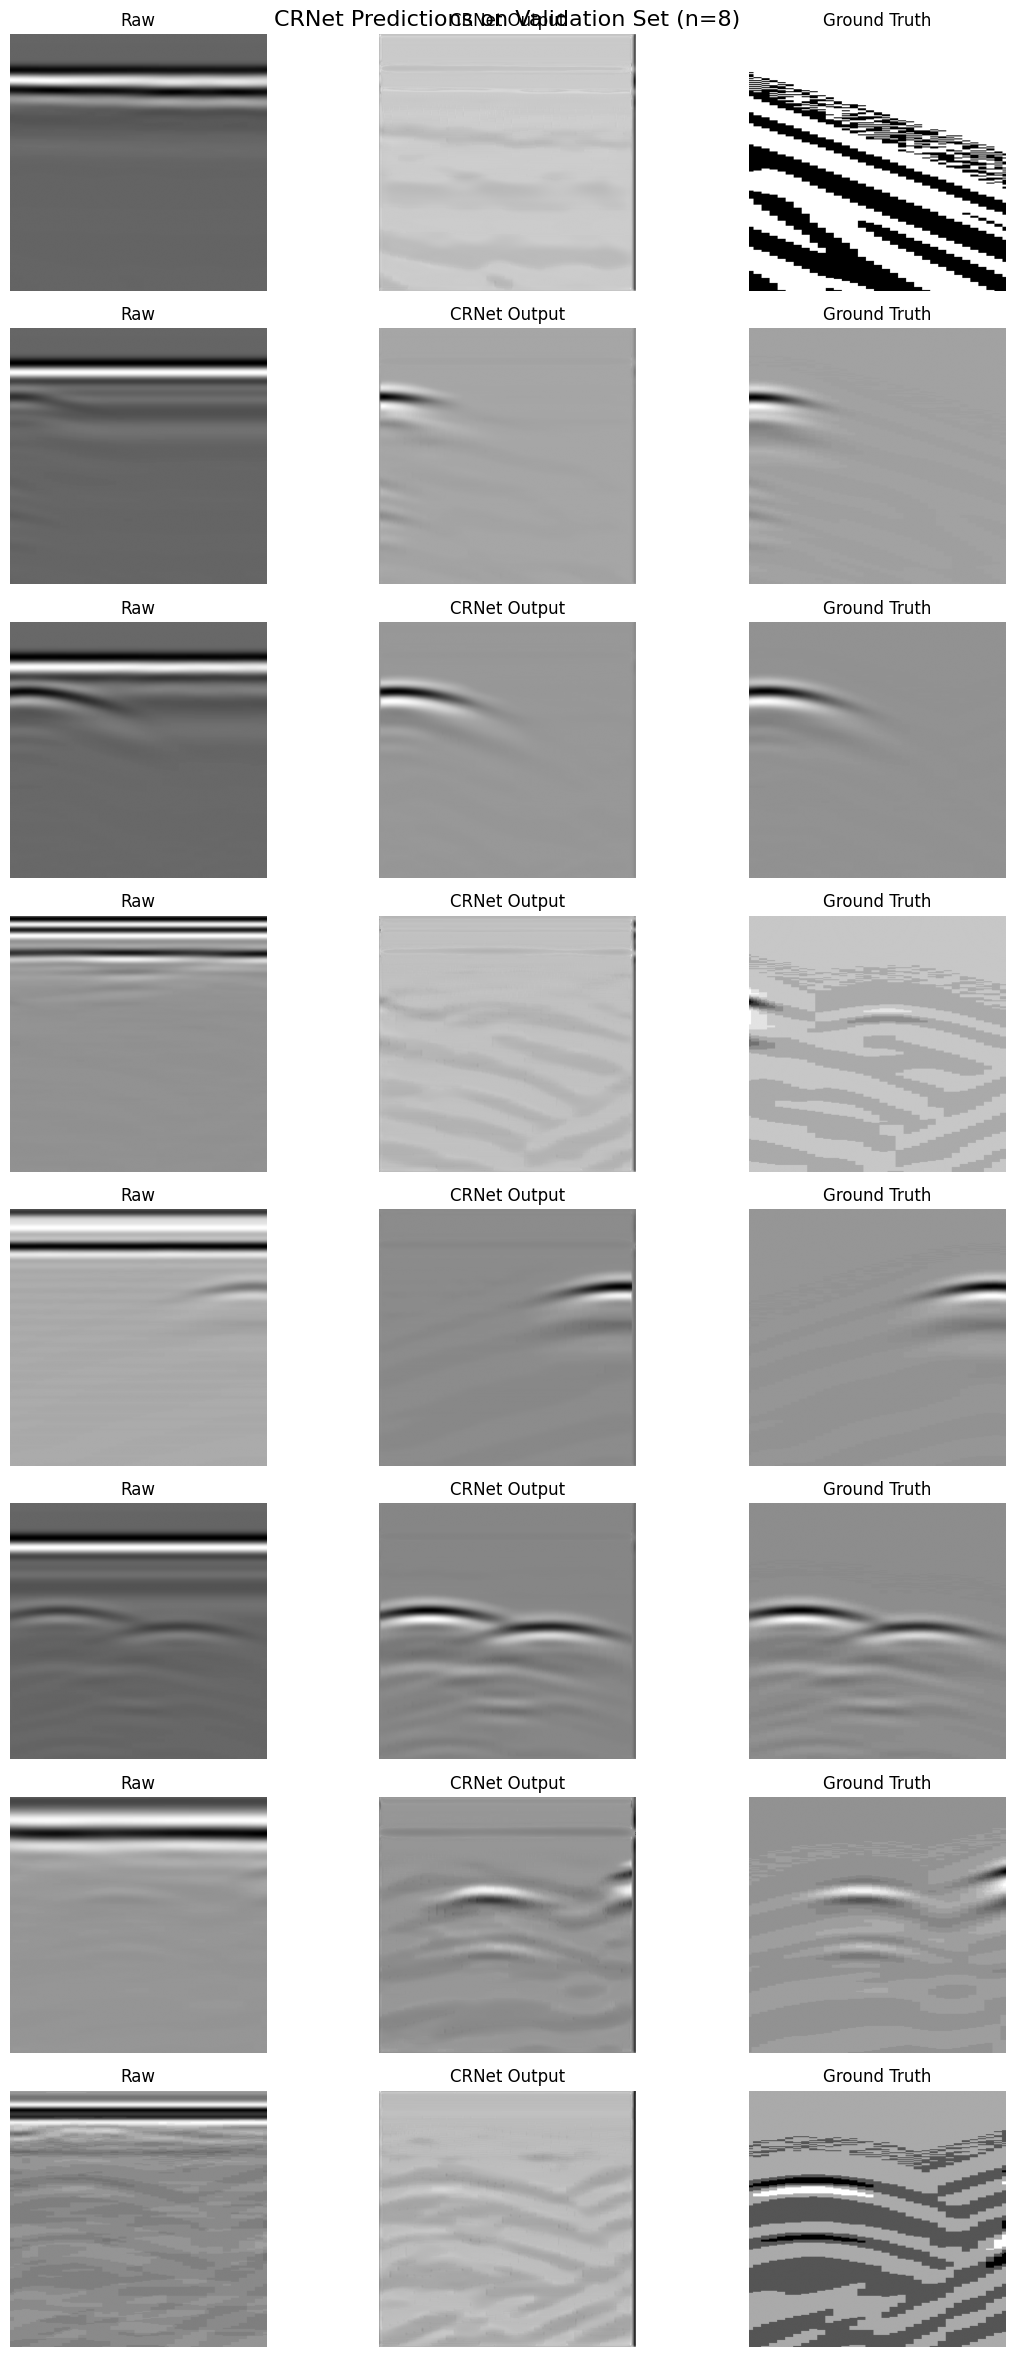

In [24]:
import matplotlib.pyplot as plt
import torch

def show_triplets(model, loader, device, num_samples=8):
    model.eval()
    
    # Get one batch
    raw, clean = next(iter(loader))
    
    # Take only desired number of samples and move to device
    raw = raw[:num_samples].to(device)
    clean = clean[:num_samples].to(device)  # Also move clean to device if needed (though not used in forward)
    
    # Inference
    with torch.no_grad():
        pred = model(raw)
    
    # Move everything back to CPU for plotting
    raw = raw.cpu()
    pred = pred.cpu()
    clean = clean.cpu()  # ← Fixed: move to CPU
    
    # Create subplots
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3 * num_samples))
    
    # Handle case when num_samples == 1 (axes is 1D)
    if num_samples == 1:
        axes = axes.reshape(1, -1)  # Make it 2D: (1, 3)
    
    for i in range(num_samples):
        # Raw input
        axes[i, 0].imshow(raw[i, 0], cmap='gray')
        axes[i, 0].set_title("Raw", fontsize=12)
        axes[i, 0].axis('off')
        
        # Model prediction
        axes[i, 1].imshow(pred[i, 0], cmap='gray')
        axes[i, 1].set_title("CRNet Output", fontsize=12)
        axes[i, 1].axis('off')
        
        # Ground truth
        axes[i, 2].imshow(clean[i, 0], cmap='gray')
        axes[i, 2].set_title("Ground Truth", fontsize=12)
        axes[i, 2].axis('off')
    
    plt.suptitle(f"CRNet Predictions on Validation Set (n={num_samples})", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Now call it safely
show_triplets(model, val_loader, device, num_samples=8)

In [29]:
torch.save(model.state_dict(), os.path.join(checkpoint_dir, "crnet_best_model.pt"))

In [26]:
def denoise_gpr_image(model, img_path, device, transform=None):
    model.eval()
    raw_img = Image.open(img_path).convert('L')
    if transform:
        input_tensor = transform(raw_img).unsqueeze(0).to(device)  # (1,1,H,W)
    else:
        input_tensor = transforms.ToTensor()(raw_img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(input_tensor)

    pred_img = pred.squeeze().cpu().numpy()
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.imshow(raw_img, cmap='gray'); plt.title('Raw B-scan'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(pred_img, cmap='gray'); plt.title('Denoised (Clutter-Free)'); plt.axis('off')
    plt.show()

    return pred_img  # for saving or further processing

### Denoising from Raw B-scan to Denoised(Clutter-Free)

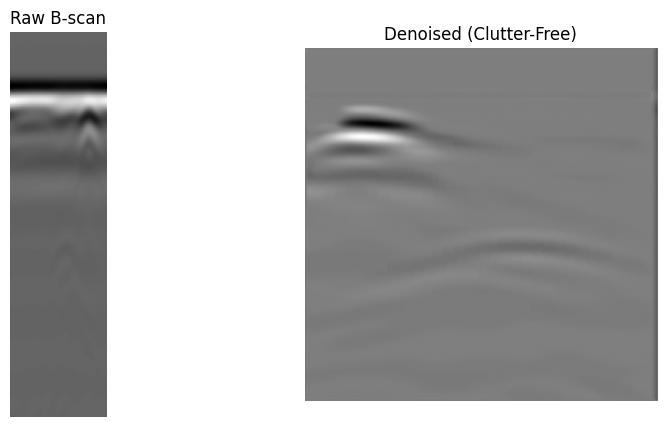

Denoised image saved!


In [27]:
# Example: replace with an actual filename from your raw_dir
sample_raw_path = os.path.join(raw_dir, '/kaggle/input/crnetdata/Dataset+Code/CLT-GPR dataset/Bscan_raw/1003.png')  # e.g., 'Bscan_001.png' – check your folder!

# Use the SAME transform as training (important for consistent size/input)
pred_img = denoise_gpr_image(model, sample_raw_path, device, transform=transform)

# Optional: Save the denoised result
denoised_pil = Image.fromarray((pred_img * 255).astype(np.uint8))  # Assuming output in [0,1]
denoised_pil.save("/kaggle/working/denoised_data_1040.png")
print("Denoised image saved!")

### Another Denoising from Raw B-scan to Denoised(Clutter-Free)

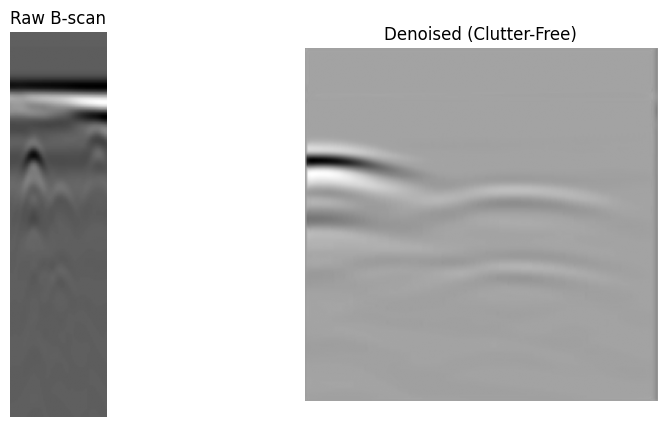

Denoised image saved! - Denoised Data Bscan_raw_1040


In [28]:
# Example: replace with an actual filename from your raw_dir
sample_raw_path = os.path.join(raw_dir, '/kaggle/input/crnetdata/Dataset+Code/CLT-GPR dataset/Bscan_raw/1040.png')  # e.g., 'Bscan_001.png' – check your folder!

# Use the SAME transform as training (important for consistent size/input)
pred_img = denoise_gpr_image(model, sample_raw_path, device, transform=transform)

# Optional: Save the denoised result
denoised_pil = Image.fromarray((pred_img * 255).astype(np.uint8))  # Assuming output in [0,1]
denoised_pil.save("/kaggle/working/denoised_data_1040.png")
print("Denoised image saved! - Denoised Data Bscan_raw_1040")

In [32]:
import torch
import os

# Define the directory where you want to save the model (Kaggle's working directory)
checkpoint_dir = '/kaggle/working/'
# Define the filename for your model
model_filename = 'crnet_best_model.pt'
# Combine the directory and filename to create the full path
save_path = os.path.join(checkpoint_dir, model_filename)
# Save the model's state_dict to the specified path
torch.save(model.state_dict(), save_path)

In [33]:
import os
print(os.listdir('/kaggle/working/'))  # Should show 'crnet_best_model.pt'

# Check file size (should be >0 if saved properly)
print(os.path.getsize('/kaggle/working/crnet_best_model.pt') / (1024*1024), "MB")

['crnet_best_model.pt', 'checkpoints', '.virtual_documents', 'denoised_data_1040.png', '.ipynb_checkpoints']
71.93426322937012 MB


### Link to Download the "crnet_best_model.pt"

In [34]:
from IPython.display import FileLink
FileLink('crnet_best_model.pt')

/kaggle/working/crnet_best_model.pt

In [36]:
from IPython.display import FileLink
display(FileLink('denoised_data_1040.png'))

/kaggle/working/denoised_data_1040.png